In [1]:
!pip -q install sentence-transformers

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import re
import os

In [3]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train (1).csv


In [4]:
df = pd.read_csv("train.csv")

In [5]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 404290
Number of columns: 6


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [8]:
df.describe()

,id,qid1,qid2,is_duplicate
count,404290.000000,404290.000000,404290.000000,404290.000000
mean,202144.500000,217243.942418,220955.655337,0.369198
std,116708.614502,157751.700002,159903.182629,0.482588
min,0.000000,1.000000,2.000000,0.000000
25%,101072.250000,74437.500000,74727.000000,0.000000
50%,202144.500000,192182.000000,197052.000000,0.000000
75%,303216.750000,346573.500000,354692.500000,1.000000
max,404289.000000,537932.000000,537933.000000,1.000000


In [9]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64


In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing value percentage:")
print(missing_percentage)

Missing value percentage:
id              0.000000
qid1            0.000000
qid2            0.000000
question1       0.000247
question2       0.000495
is_duplicate    0.000000
dtype: float64


In [11]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 0


In [13]:
class_counts = df["is_duplicate"].value_counts()

print(class_counts)

is_duplicate
0    255027
1    149263
Name: count, dtype: int64


In [14]:
class_percentage = df["is_duplicate"].value_counts(normalize=True) * 100

print(class_percentage)

is_duplicate
0    63.080215
1    36.919785
Name: proportion, dtype: float64


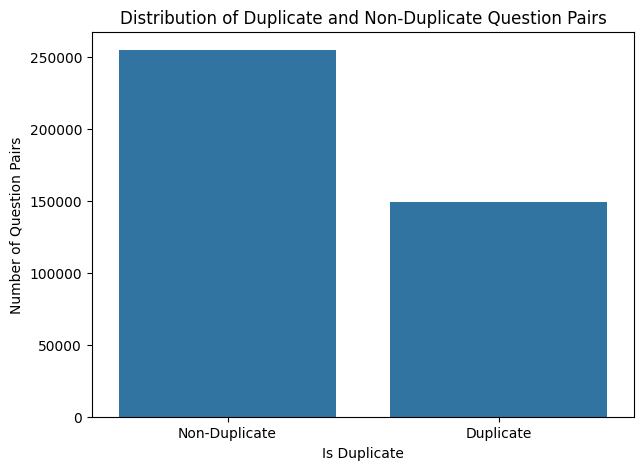

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="is_duplicate"
)

plt.title("Distribution of Duplicate and Non-Duplicate Question Pairs")
plt.xlabel("Is Duplicate")
plt.ylabel("Number of Question Pairs")
plt.xticks([0, 1], ["Non-Duplicate", "Duplicate"])

plt.show()

In [16]:
df["q1_word_count"] = df["question1"].fillna("").apply(
    lambda x: len(str(x).split())
)

df["q2_word_count"] = df["question2"].fillna("").apply(
    lambda x: len(str(x).split())
)

In [17]:
df["q1_char_count"] = df["question1"].fillna("").apply(len)

df["q2_char_count"] = df["question2"].fillna("").apply(len)

In [18]:
df[
    [
        "q1_word_count",
        "q2_word_count",
        "q1_char_count",
        "q2_char_count"
    ]
].describe()

,q1_word_count,q2_word_count,q1_char_count,q2_char_count
count,404290.000000,404290.000000,404290.000000,404290.000000
mean,10.942207,11.181986,59.536709,60.108365
std,5.428828,6.305254,29.940655,33.863870
min,0.000000,0.000000,0.000000,0.000000
25%,7.000000,7.000000,39.000000,39.000000
50%,10.000000,10.000000,52.000000,51.000000
75%,13.000000,13.000000,72.000000,72.000000
max,125.000000,237.000000,623.000000,1169.000000


In [19]:
df.groupby("is_duplicate")[
    ["q1_word_count", "q2_word_count"]
].mean()

,q1_word_count,q2_word_count
is_duplicate,,
0,11.582825,11.955722
1,9.847665,9.859999


In [20]:
def lexical_overlap(q1, q2):
    words1 = set(str(q1).lower().split())
    words2 = set(str(q2).lower().split())

    if len(words1.union(words2)) == 0:
        return 0

    return len(words1.intersection(words2)) / len(words1.union(words2))

In [21]:
df["lexical_overlap"] = df.apply(
    lambda row: lexical_overlap(
        row["question1"],
        row["question2"]
    ),
    axis=1
)

In [22]:
df.groupby("is_duplicate")["lexical_overlap"].mean()

,lexical_overlap
is_duplicate,
0,0.264438
1,0.430998


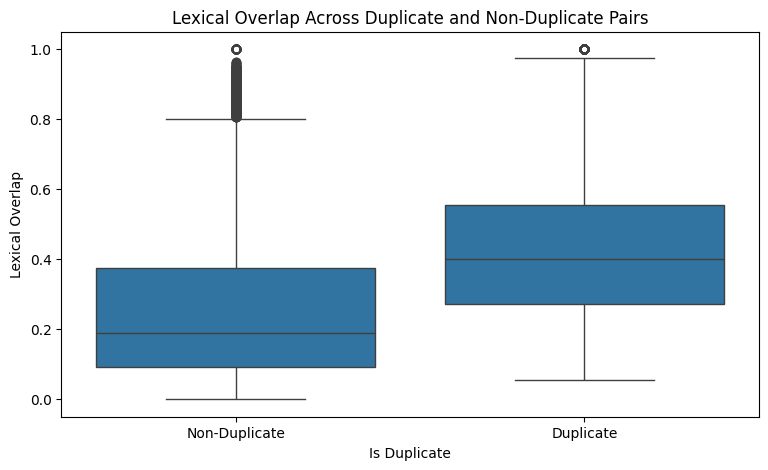

In [23]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="is_duplicate",
    y="lexical_overlap"
)

plt.title("Lexical Overlap Across Duplicate and Non-Duplicate Pairs")
plt.xlabel("Is Duplicate")
plt.ylabel("Lexical Overlap")
plt.xticks([0, 1], ["Non-Duplicate", "Duplicate"])

plt.show()

In [24]:
high_overlap_non_duplicate = df[
    (df["is_duplicate"] == 0) &
    (df["lexical_overlap"] >= 0.8)
].sort_values(
    "lexical_overlap",
    ascending=False
)

high_overlap_non_duplicate[
    ["question1", "question2", "lexical_overlap"]
].head(10)

,question1,question2,lexical_overlap
79791,What's the best country to visit in the summer?,What's the best country to visit in summer?,1.0
79800,What is the difference between Computer Scienc...,What is the difference between computer scienc...,1.0
281293,Can anyone solve the puzzle mentioned in image...,Can anyone solve the puzzle mentioned in the i...,1.0
121914,Is the practice of liberal values only a way t...,Is the practice of liberal values only a way t...,1.0
115053,What are the chances I could be pregnant?,What are the chances I could be pregnant?,1.0
117747,Biochemistry: What are some molecules that are...,Biochemistry: What are some molecules that are...,1.0
377965,What is the future of HTML5 game development?,What is the future of Of HTML5 game development?,1.0
402597,Can evaporated milk be used as an alternative ...,Can sweetened condensed milk be used as an alt...,1.0
377288,How can I create an app similar to Uber/Ola on...,How can I create an app similar to Uber/Ola on...,1.0
124988,Who is this this guy in the picture?,Who is the guy in this picture?,1.0


In [25]:
low_overlap_duplicate = df[
    (df["is_duplicate"] == 1) &
    (df["lexical_overlap"] <= 0.2)
].sort_values(
    "lexical_overlap"
)

low_overlap_duplicate[
    ["question1", "question2", "lexical_overlap"]
].head(10)

,question1,question2,lexical_overlap
71716,How do parents feel when their kid has depress...,What is it like to have a child with depression?,0.055556
170654,Are there any theories on how a person can bec...,What is it like to be psychic?,0.058824
365102,How do I get into Harvard as an undergrad?,What should be done to get admission in harvard?,0.058824
164232,"When should I use ""who"" and when should I use ...",How can we use who or whom in a sentence?,0.062500
361993,What should I do if I want to be a rich person?,How can we become rich soon?,0.062500
374157,Do you believe in free will or determinism?,How can we be sure that we have free will?,0.062500
35520,What does it feel like to be poor?,How do you describe the feeling of being poor?,0.062500
235243,Is there any way of knowing if a guy is gay?,How do I know your gay?,0.066667
195611,How can I enlarge my penis?,Is it possible to increase the size of a penis?,0.066667
165660,How was your peace corps experience?,What is it like to serve in the Peace Corps?,0.066667


In [28]:
# Collect all unique question IDs
all_qids = pd.unique(
    pd.concat([
        df["qid1"],
        df["qid2"]
    ], ignore_index=True)
)

print("Total unique question IDs:", len(all_qids))

Total unique question IDs: 537933


In [29]:
from sklearn.model_selection import train_test_split

train_qids, temp_qids = train_test_split(
    all_qids,
    test_size=0.30,
    random_state=42
)

val_qids, test_qids = train_test_split(
    temp_qids,
    test_size=0.50,
    random_state=42
)

print("Training question IDs:", len(train_qids))
print("Validation question IDs:", len(val_qids))
print("Test question IDs:", len(test_qids))

Training question IDs: 376553
Validation question IDs: 80690
Test question IDs: 80690


In [30]:
train_qids = set(train_qids)
val_qids = set(val_qids)
test_qids = set(test_qids)

In [31]:
train_mask = (
    df["qid1"].isin(train_qids) &
    df["qid2"].isin(train_qids)
)

val_mask = (
    df["qid1"].isin(val_qids) &
    df["qid2"].isin(val_qids)
)

test_mask = (
    df["qid1"].isin(test_qids) &
    df["qid2"].isin(test_qids)
)

train_df = df[train_mask].copy()
val_df = df[val_mask].copy()
test_df = df[test_mask].copy()

In [32]:
print("Training pairs:", len(train_df))
print("Validation pairs:", len(val_df))
print("Test pairs:", len(test_df))

print("\nTotal pairs retained:",
      len(train_df) + len(val_df) + len(test_df))

print("Original pairs:", len(df))

Training pairs: 198177
Validation pairs: 8952
Test pairs: 9029

Total pairs retained: 216158
Original pairs: 404290


In [33]:
print("Training class distribution:")
print(train_df["is_duplicate"].value_counts(normalize=True))

print("\nValidation class distribution:")
print(val_df["is_duplicate"].value_counts(normalize=True))

print("\nTest class distribution:")
print(test_df["is_duplicate"].value_counts(normalize=True))

Training class distribution:
is_duplicate
0    0.630431
1    0.369569
Name: proportion, dtype: float64

Validation class distribution:
is_duplicate
0    0.630809
1    0.369191
Name: proportion, dtype: float64

Test class distribution:
is_duplicate
0    0.639938
1    0.360062
Name: proportion, dtype: float64


In [34]:
train_question_ids = set(train_df["qid1"]).union(
    set(train_df["qid2"])
)

val_question_ids = set(val_df["qid1"]).union(
    set(val_df["qid2"])
)

test_question_ids = set(test_df["qid1"]).union(
    set(test_df["qid2"])
)

print("Train ∩ Validation:",
      len(train_question_ids.intersection(val_question_ids)))

print("Train ∩ Test:",
      len(train_question_ids.intersection(test_question_ids)))

print("Validation ∩ Test:",
      len(val_question_ids.intersection(test_question_ids)))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [36]:
# Section 13: TF-IDF Baseline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Fill missing values just in case
train_q1 = train_df["question1"].fillna("")
train_q2 = train_df["question2"].fillna("")

val_q1 = val_df["question1"].fillna("")
val_q2 = val_df["question2"].fillna("")

test_q1 = test_df["question1"].fillna("")
test_q2 = test_df["question2"].fillna("")

# Combine all training questions for fitting TF-IDF
all_train_questions = pd.concat(
    [train_q1, train_q2],
    ignore_index=True
)

# TF-IDF vectorizer
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=100000
)

# Fit ONLY on training questions
tfidf.fit(all_train_questions)

print("TF-IDF vocabulary size:", len(tfidf.vocabulary_))

TF-IDF vocabulary size: 100000


In [37]:
# Transform validation questions into TF-IDF vectors
val_q1_tfidf = tfidf.transform(val_q1)
val_q2_tfidf = tfidf.transform(val_q2)

# Calculate cosine similarity for each question pair
val_similarity = cosine_similarity(
    val_q1_tfidf,
    val_q2_tfidf
).diagonal()

print("Validation pairs:", len(val_similarity))
print("Minimum similarity:", val_similarity.min())
print("Maximum similarity:", val_similarity.max())
print("Mean similarity:", val_similarity.mean())

Validation pairs: 8952
Minimum similarity: 0.0
Maximum similarity: 1.0000000000000004
Mean similarity: 0.4620904138979911


In [38]:
# Section 13C: Select threshold using validation set

import numpy as np

y_val = val_df["is_duplicate"].values

thresholds = np.arange(0.10, 0.91, 0.01)

results = []

for threshold in thresholds:
    y_pred = (val_similarity >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

# Find threshold with highest F1
best_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print("Best threshold:", round(best_row["threshold"], 2))
print("Validation Accuracy:", round(best_row["accuracy"], 4))
print("Validation Precision:", round(best_row["precision"], 4))
print("Validation Recall:", round(best_row["recall"], 4))
print("Validation F1:", round(best_row["f1"], 4))

Best threshold: 0.17
Validation Accuracy: 0.5412
Validation Precision: 0.4428
Validation Recall: 0.9398
Validation F1: 0.602


In [39]:
# Section 13D: Final TF-IDF Test Evaluation

# Transform test questions
test_q1_tfidf = tfidf.transform(test_q1)
test_q2_tfidf = tfidf.transform(test_q2)

# Calculate cosine similarity
test_similarity = cosine_similarity(
    test_q1_tfidf,
    test_q2_tfidf
).diagonal()

# Use the threshold selected on validation data
best_threshold = best_row["threshold"]

y_test = test_df["is_duplicate"].values
y_test_pred = (test_similarity >= best_threshold).astype(int)

# Evaluation metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

print("TF-IDF TEST RESULTS")
print("-------------------")
print("Threshold:", round(best_threshold, 2))
print("Accuracy:", round(test_accuracy, 4))
print("Precision:", round(test_precision, 4))
print("Recall:", round(test_recall, 4))
print("F1 Score:", round(test_f1, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

TF-IDF TEST RESULTS
-------------------
Threshold: 0.17
Accuracy: 0.5348
Precision: 0.4331
Recall: 0.9449
F1 Score: 0.594

Confusion Matrix:
[[1757 4021]
 [ 179 3072]]


In [40]:
# Section 14A: Install Sentence Transformers

!pip -q install sentence-transformers

In [41]:
import sentence_transformers

print("Sentence Transformers version:", sentence_transformers.__version__)

Sentence Transformers version: 5.7.0


In [42]:
# Section 14B: Load Sentence-BERT model

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully.")
print("Embedding dimension:", model.get_sentence_embedding_dimension())

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully.
Embedding dimension: 384


/tmp/ipykernel_462/3323889263.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Embedding dimension:", model.get_sentence_embedding_dimension())


In [43]:
# Section 14C: Generate Semantic Embeddings

# Get unique validation and test questions
val_questions = pd.unique(
    pd.concat([val_q1, val_q2], ignore_index=True)
)

test_questions = pd.unique(
    pd.concat([test_q1, test_q2], ignore_index=True)
)

print("Unique validation questions:", len(val_questions))
print("Unique test questions:", len(test_questions))

# Generate embeddings
val_embeddings = model.encode(
    val_questions,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

test_embeddings = model.encode(
    test_questions,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Validation embedding shape:", val_embeddings.shape)
print("Test embedding shape:", test_embeddings.shape)

Unique validation questions: 15543
Unique test questions: 15964


Batches:   0%|          | 0/243 [00:00<?, ?it/s]

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Validation embedding shape: (15543, 384)
Test embedding shape: (15964, 384)


In [44]:
# Section 14D: Calculate Semantic Similarity

# Create lookup dictionaries for question -> embedding
val_embedding_lookup = {
    question: embedding
    for question, embedding in zip(val_questions, val_embeddings)
}

test_embedding_lookup = {
    question: embedding
    for question, embedding in zip(test_questions, test_embeddings)
}

# Get embeddings for each question in every validation pair
val_q1_embeddings = np.array([
    val_embedding_lookup[q]
    for q in val_q1
])

val_q2_embeddings = np.array([
    val_embedding_lookup[q]
    for q in val_q2
])

# Cosine similarity = dot product because embeddings are normalized
val_semantic_similarity = np.sum(
    val_q1_embeddings * val_q2_embeddings,
    axis=1
)

print("Validation semantic similarity calculated.")
print("Minimum:", val_semantic_similarity.min())
print("Maximum:", val_semantic_similarity.max())
print("Mean:", val_semantic_similarity.mean())
print("Number of pairs:", len(val_semantic_similarity))

Validation semantic similarity calculated.
Minimum: -0.15143263
Maximum: 1.0000002
Mean: 0.6734674
Number of pairs: 8952


In [45]:
# Section 14E: Select Semantic Similarity Threshold

y_val = val_df["is_duplicate"].values

semantic_thresholds = np.arange(0.10, 0.91, 0.01)

semantic_results = []

for threshold in semantic_thresholds:
    y_pred = (val_semantic_similarity >= threshold).astype(int)

    semantic_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0)
    })

semantic_threshold_results = pd.DataFrame(semantic_results)

# Select threshold with highest validation F1
best_semantic_row = semantic_threshold_results.loc[
    semantic_threshold_results["f1"].idxmax()
]

print("Best semantic threshold:", round(best_semantic_row["threshold"], 2))
print("Validation Accuracy:", round(best_semantic_row["accuracy"], 4))
print("Validation Precision:", round(best_semantic_row["precision"], 4))
print("Validation Recall:", round(best_semantic_row["recall"], 4))
print("Validation F1:", round(best_semantic_row["f1"], 4))

Best semantic threshold: 0.73
Validation Accuracy: 0.753
Validation Precision: 0.6129
Validation Recall: 0.8986
Validation F1: 0.7287


In [46]:
# Section 14F: Final Sentence-BERT Test Evaluation

# Get embeddings for each question in the test pairs
test_q1_embeddings = np.array([
    test_embedding_lookup[q]
    for q in test_q1
])

test_q2_embeddings = np.array([
    test_embedding_lookup[q]
    for q in test_q2
])

# Calculate semantic similarity
test_semantic_similarity = np.sum(
    test_q1_embeddings * test_q2_embeddings,
    axis=1
)

# Lock the threshold selected using validation data
best_semantic_threshold = best_semantic_row["threshold"]

y_test = test_df["is_duplicate"].values

y_test_semantic_pred = (
    test_semantic_similarity >= best_semantic_threshold
).astype(int)

# Evaluation metrics
semantic_test_accuracy = accuracy_score(
    y_test,
    y_test_semantic_pred
)

semantic_test_precision = precision_score(
    y_test,
    y_test_semantic_pred,
    zero_division=0
)

semantic_test_recall = recall_score(
    y_test,
    y_test_semantic_pred,
    zero_division=0
)

semantic_test_f1 = f1_score(
    y_test,
    y_test_semantic_pred,
    zero_division=0
)

print("SENTENCE-BERT TEST RESULTS")
print("--------------------------")
print("Threshold:", round(best_semantic_threshold, 2))
print("Accuracy:", round(semantic_test_accuracy, 4))
print("Precision:", round(semantic_test_precision, 4))
print("Recall:", round(semantic_test_recall, 4))
print("F1 Score:", round(semantic_test_f1, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_semantic_pred))

SENTENCE-BERT TEST RESULTS
--------------------------
Threshold: 0.73
Accuracy: 0.7649
Precision: 0.6184
Recall: 0.9059
F1 Score: 0.7351

Confusion Matrix:
[[3961 1817]
 [ 306 2945]]


In [47]:
# Section 15A: Calculate Lexical Overlap for Test Pairs

def jaccard_similarity(q1, q2):
    words1 = set(str(q1).lower().split())
    words2 = set(str(q2).lower().split())

    if not words1 and not words2:
        return 1.0

    if not words1 or not words2:
        return 0.0

    return len(words1.intersection(words2)) / len(
        words1.union(words2)
    )

test_lexical_overlap = np.array([
    jaccard_similarity(q1, q2)
    for q1, q2 in zip(test_q1, test_q2)
])

print("Test lexical overlap calculated.")
print("Minimum:", round(test_lexical_overlap.min(), 4))
print("Maximum:", round(test_lexical_overlap.max(), 4))
print("Mean:", round(test_lexical_overlap.mean(), 4))
print("Median:", round(np.median(test_lexical_overlap), 4))

Test lexical overlap calculated.
Minimum: 0.0
Maximum: 1.0
Mean: 0.3242
Median: 0.2727


In [48]:
# Section 15B: Audit Performance by Lexical Overlap

overlap_cutoff = np.median(test_lexical_overlap)

low_overlap_mask = test_lexical_overlap < overlap_cutoff
high_overlap_mask = test_lexical_overlap >= overlap_cutoff

def evaluate_subgroup(mask, subgroup_name):
    y_true = y_test[mask]
    y_pred = y_test_semantic_pred[mask]

    print(f"\n{subgroup_name}")
    print("-" * len(subgroup_name))
    print("Number of pairs:", len(y_true))
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))
    print("Recall:", round(recall_score(y_true, y_pred, zero_division=0), 4))
    print("F1:", round(f1_score(y_true, y_pred, zero_division=0), 4))

print("Lexical overlap cutoff:", round(overlap_cutoff, 4))

evaluate_subgroup(
    low_overlap_mask,
    "LOW LEXICAL OVERLAP"
)

evaluate_subgroup(
    high_overlap_mask,
    "HIGH LEXICAL OVERLAP"
)

Lexical overlap cutoff: 0.2727

LOW LEXICAL OVERLAP
-------------------
Number of pairs: 4446
Accuracy: 0.8561
Precision: 0.5647
Recall: 0.7928
F1: 0.6596

HIGH LEXICAL OVERLAP
--------------------
Number of pairs: 4583
Accuracy: 0.6764
Precision: 0.6346
Recall: 0.9417
F1: 0.7582


In [49]:
# Section 15C: Calculate Question Length for Test Pairs

def word_count(text):
    return len(str(text).split())

test_q1_length = np.array([
    word_count(q) for q in test_q1
])

test_q2_length = np.array([
    word_count(q) for q in test_q2
])

# Average length of the two questions in each pair
test_pair_length = (
    test_q1_length + test_q2_length
) / 2

length_cutoff = np.median(test_pair_length)

print("Median pair word count:", round(length_cutoff, 2))
print("Minimum pair length:", test_pair_length.min())
print("Maximum pair length:", test_pair_length.max())

Median pair word count: 10.0
Minimum pair length: 2.5
Maximum pair length: 133.5


In [50]:
# Section 15D: Audit Performance by Question Length

short_pair_mask = test_pair_length < length_cutoff
long_pair_mask = test_pair_length >= length_cutoff

evaluate_subgroup(
    short_pair_mask,
    "SHORT QUESTION PAIRS"
)

evaluate_subgroup(
    long_pair_mask,
    "LONG QUESTION PAIRS"
)


SHORT QUESTION PAIRS
--------------------
Number of pairs: 4345
Accuracy: 0.7381
Precision: 0.6378
Recall: 0.9416
F1: 0.7605

LONG QUESTION PAIRS
-------------------
Number of pairs: 4684
Accuracy: 0.7897
Precision: 0.5899
Recall: 0.8544
F1: 0.6979


In [51]:
# Section 16A: Create Error Analysis Dataset

error_analysis = test_df[
    ["question1", "question2", "is_duplicate"]
].copy()

error_analysis["semantic_similarity"] = test_semantic_similarity
error_analysis["prediction"] = y_test_semantic_pred

# Label each prediction
def classify_prediction(row):
    if row["is_duplicate"] == 1 and row["prediction"] == 1:
        return "True Positive"
    elif row["is_duplicate"] == 0 and row["prediction"] == 1:
        return "False Positive"
    elif row["is_duplicate"] == 1 and row["prediction"] == 0:
        return "False Negative"
    else:
        return "True Negative"

error_analysis["prediction_type"] = error_analysis.apply(
    classify_prediction,
    axis=1
)

print(error_analysis["prediction_type"].value_counts())

prediction_type
True Negative     3961
True Positive     2945
False Positive    1817
False Negative     306
Name: count, dtype: int64


In [52]:
# Section 16B: Representative False Positives

false_positives = error_analysis[
    error_analysis["prediction_type"] == "False Positive"
].sort_values(
    "semantic_similarity",
    ascending=False
)

print("Top 10 False Positives")
print("=" * 80)

for i, (_, row) in enumerate(false_positives.head(10).iterrows(), 1):
    print(f"\nExample {i}")
    print("Question 1:", row["question1"])
    print("Question 2:", row["question2"])
    print("Semantic similarity:", round(row["semantic_similarity"], 4))
    print("Actual label:", row["is_duplicate"])

Top 10 False Positives

Example 1
Question 1: How do I convince youth to celebrate Indian festivals in the traditional way?
Question 2: How do I convince youth to celebrate Indian festivals in traditional way?
Semantic similarity: 0.9991
Actual label: 0

Example 2
Question 1: Is human interaction possible in an absolute silence?
Question 2: Is human interaction possible in absolute silence?
Semantic similarity: 0.996
Actual label: 0

Example 3
Question 1: What is it like to be gay in Hong Kong?
Question 2: What's it like to be gay in Hong Kong?
Semantic similarity: 0.9959
Actual label: 0

Example 4
Question 1: What is the single most effective piece of financial advice you've ever received?
Question 2: What is the single, most effective piece of financial advice you've ever received?
Semantic similarity: 0.995
Actual label: 0

Example 5
Question 1: How can I switch my phone from Verizon to Straight Talk?
Question 2: How can I switch my phone from straight talk to Verizon?
Semantic simi

In [53]:
# Section 16C: Representative False Negatives

false_negatives = error_analysis[
    error_analysis["prediction_type"] == "False Negative"
].sort_values(
    "semantic_similarity",
    ascending=False
)

print("Top 10 False Negatives")
print("=" * 80)

for i, (_, row) in enumerate(false_negatives.head(10).iterrows(), 1):
    print(f"\nExample {i}")
    print("Question 1:", row["question1"])
    print("Question 2:", row["question2"])
    print("Semantic similarity:", round(row["semantic_similarity"], 4))
    print("Actual label:", row["is_duplicate"])

Top 10 False Negatives

Example 1
Question 1: How do I get rid of scalp acne?
Question 2: How do I to get rid of acne scars?
Semantic similarity: 0.7299
Actual label: 1

Example 2
Question 1: What are the high level procedural programming languages?
Question 2: What is the difference between a procedural language and a programming language?
Semantic similarity: 0.7299
Actual label: 1

Example 3
Question 1: Career Advice: What are the success tricks for preparing Gate in 3 months?
Question 2: What is the best way to prepare for gate 2016 (EE) in 3 months?
Semantic similarity: 0.7297
Actual label: 1

Example 4
Question 1: How do I get rid of lethargy?
Question 2: What are some good ways to get rid of weekend lethargy?
Semantic similarity: 0.7296
Actual label: 1

Example 5
Question 1: How do you get rid of a addiction?
Question 2: What is the best way to get rid of addictions like Facebook and WhatsApp?
Semantic similarity: 0.7295
Actual label: 1

Example 6
Question 1: What problems did y

In [54]:
# Section 17A: Final Model Comparison

final_results = pd.DataFrame({
    "Model": [
        "TF-IDF Baseline",
        "Sentence-BERT"
    ],
    "Accuracy": [
        test_accuracy,
        semantic_test_accuracy
    ],
    "Precision": [
        test_precision,
        semantic_test_precision
    ],
    "Recall": [
        test_recall,
        semantic_test_recall
    ],
    "F1 Score": [
        test_f1,
        semantic_test_f1
    ]
})

print(final_results.round(4).to_string(index=False))

print("\nSentence-BERT Improvement over TF-IDF:")
print(
    "Accuracy:",
    round((semantic_test_accuracy - test_accuracy) * 100, 2),
    "percentage points"
)
print(
    "Precision:",
    round((semantic_test_precision - test_precision) * 100, 2),
    "percentage points"
)
print(
    "Recall:",
    round((semantic_test_recall - test_recall) * 100, 2),
    "percentage points"
)
print(
    "F1:",
    round((semantic_test_f1 - test_f1) * 100, 2),
    "percentage points"
)

          Model  Accuracy  Precision  Recall  F1 Score
TF-IDF Baseline    0.5348     0.4331  0.9449    0.5940
  Sentence-BERT    0.7649     0.6184  0.9059    0.7351

Sentence-BERT Improvement over TF-IDF:
Accuracy: 23.0 percentage points
Precision: 18.53 percentage points
Recall: -3.91 percentage points
F1: 14.11 percentage points


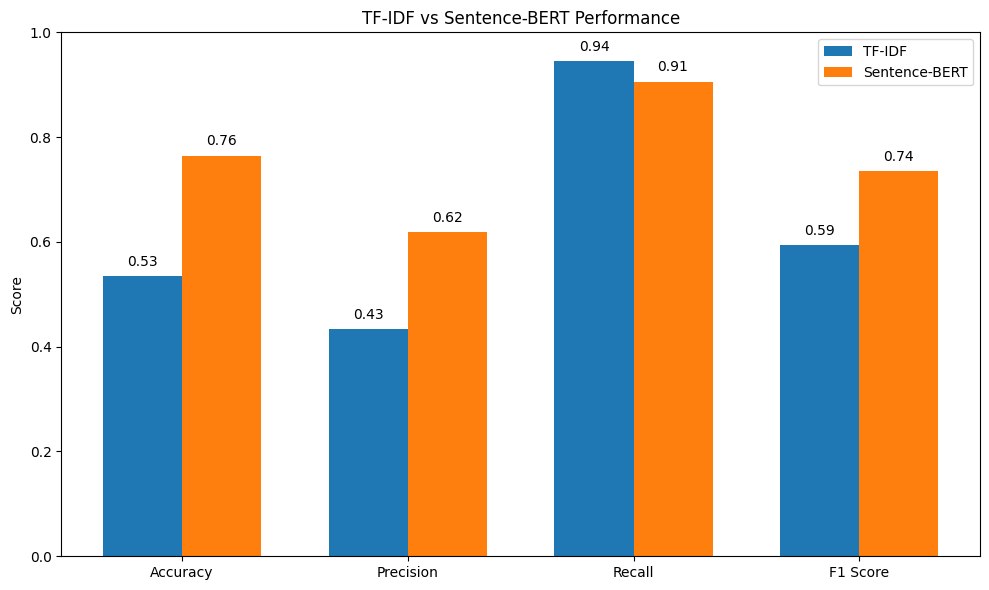

In [55]:
# Section 17B: Model Performance Comparison

import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

tfidf_scores = [
    test_accuracy,
    test_precision,
    test_recall,
    test_f1
]

sbert_scores = [
    semantic_test_accuracy,
    semantic_test_precision,
    semantic_test_recall,
    semantic_test_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, tfidf_scores, width, label="TF-IDF")
plt.bar(x + width/2, sbert_scores, width, label="Sentence-BERT")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("TF-IDF vs Sentence-BERT Performance")
plt.ylim(0, 1)

for i, value in enumerate(tfidf_scores):
    plt.text(i - width/2, value + 0.02, f"{value:.2f}", ha="center")

for i, value in enumerate(sbert_scores):
    plt.text(i + width/2, value + 0.02, f"{value:.2f}", ha="center")

plt.legend()
plt.tight_layout()
plt.show()

<Figure size 700x600 with 0 Axes>

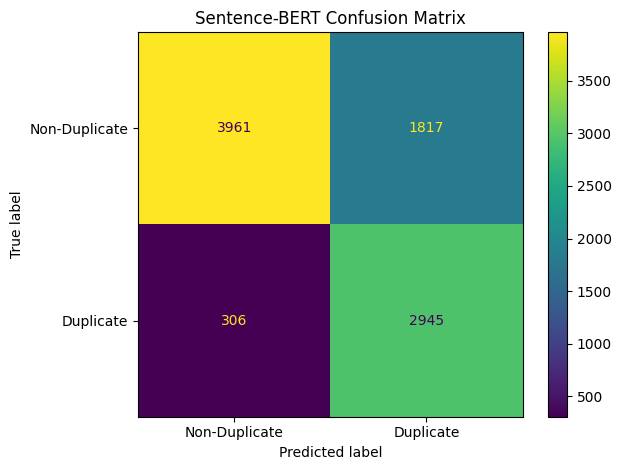

In [56]:
# Section 17C: Sentence-BERT Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_test_semantic_pred
)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Duplicate", "Duplicate"]
)

disp.plot(values_format="d")

plt.title("Sentence-BERT Confusion Matrix")
plt.tight_layout()
plt.show()
